# 01 · Train fMRI → CLIP embedding (Experiment 1)
**Question:** does the model learn a useful CLIP representation from fMRI?

Training calls `src.training.train_clip` — the exact function used by `scripts/02_train_fmri_to_clip.py`. Set `RESUME=True` to continue from `last.pt`.

In [1]:
# Run from the PROJECT ROOT so relative paths (configs/, data/, outputs/)
# resolve exactly like the scripts do — this avoids a notebooks/data/... mismatch.
import sys, os
_root = os.getcwd()
while _root != os.path.dirname(_root):
    if os.path.isdir(os.path.join(_root, 'src')) and os.path.isdir(os.path.join(_root, 'configs')):
        break
    _root = os.path.dirname(_root)
os.chdir(_root)
sys.path.insert(0, _root)
print('project root:', os.getcwd())
import numpy as np
import matplotlib.pyplot as plt
from src.utils import load_config
from src.training import train_clip
from src.utils import get_experiment_paths, load_json

RESUME = False
CHECKPOINT_PATH = 'outputs/exp01_fmri_to_clip/checkpoints/last.pt'
cfg = load_config('configs/exp01_fmri_to_clip.yaml')
# Precompute CLIP features first: python scripts/01_precompute_clip.py --config configs/exp01_fmri_to_clip.yaml

project root: c:\Users\xxdia\Documents\TFM\tfm_fmri_diffusion


In [2]:
# Train (reduce epochs for a quick interactive run):
cfg['training']['epochs'] = 100
result = train_clip(cfg, resume=('auto' if RESUME else None))
result['metrics']

10:33:09 | INFO    | train | Experiment dir: outputs\exp01_fmri_to_clip | device: cuda | lowlevel: False
10:33:09 | INFO    | datamodule | Loading cached split metadata: data\processed\metadata_subj01.csv
10:33:09 | INFO    | datamodule | Prepared 1 subject(s) ['subj01'] | test_split=official | samples: {'train': np.int64(8857), 'val': np.int64(984), 'test': np.int64(159)} | voxels: {'subj01': 39548}
10:33:10 | INFO    | train | Starting training from scratch (no resume).
10:33:24 | INFO    | trainer |   epoch 0 it 0/138 | loss 5.1806
10:33:28 | INFO    | trainer |   epoch 0 it 50/138 | loss 4.5741
10:33:32 | INFO    | trainer |   epoch 0 it 100/138 | loss 4.0212


c:\Users\xxdia\Documents\TFM\tfm_fmri_diffusion\.tfm_fmri_diffusion_3_11\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


10:34:03 | INFO    | train | epoch 0 | train 3.7416 | val_loss 2.6863 | val_top5 0.2744 * | 54s
10:34:18 | INFO    | trainer |   epoch 1 it 0/138 | loss 2.5234
10:34:22 | INFO    | trainer |   epoch 1 it 50/138 | loss 2.4775
10:34:26 | INFO    | trainer |   epoch 1 it 100/138 | loss 2.4380
10:34:54 | INFO    | train | epoch 1 | train 2.4078 | val_loss 2.3036 | val_top5 0.4248 * | 50s
10:35:08 | INFO    | trainer |   epoch 2 it 0/138 | loss 1.8803
10:35:12 | INFO    | trainer |   epoch 2 it 50/138 | loss 1.8392
10:35:16 | INFO    | trainer |   epoch 2 it 100/138 | loss 1.8449
10:35:43 | INFO    | train | epoch 2 | train 1.8440 | val_loss 2.0840 | val_top5 0.5620 * | 49s
10:35:57 | INFO    | trainer |   epoch 3 it 0/138 | loss 1.3922
10:36:01 | INFO    | trainer |   epoch 3 it 50/138 | loss 1.3889
10:36:05 | INFO    | trainer |   epoch 3 it 100/138 | loss 1.3969
10:36:32 | INFO    | train | epoch 3 | train 1.4040 | val_loss 1.9948 | val_top5 0.5996 * | 49s
10:36:46 | INFO    | trainer | 

KeyboardInterrupt: 

## Loss and retrieval curves

In [5]:
%matplotlib inline

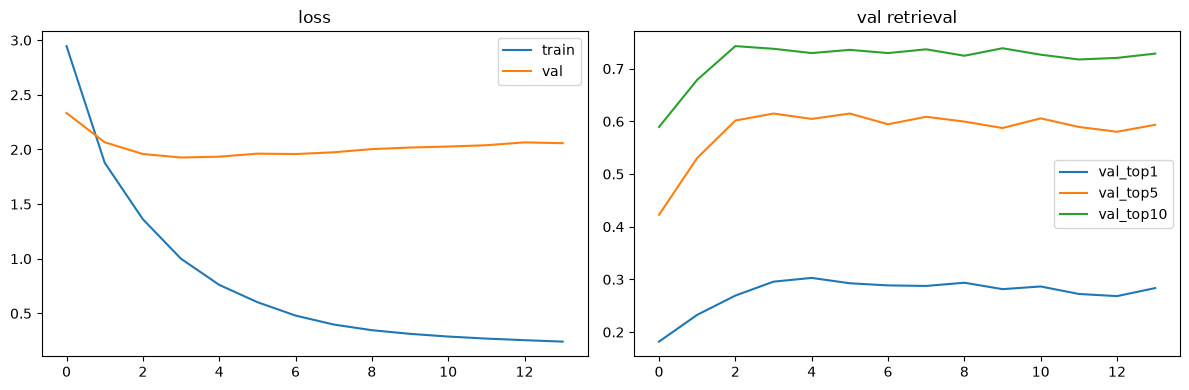

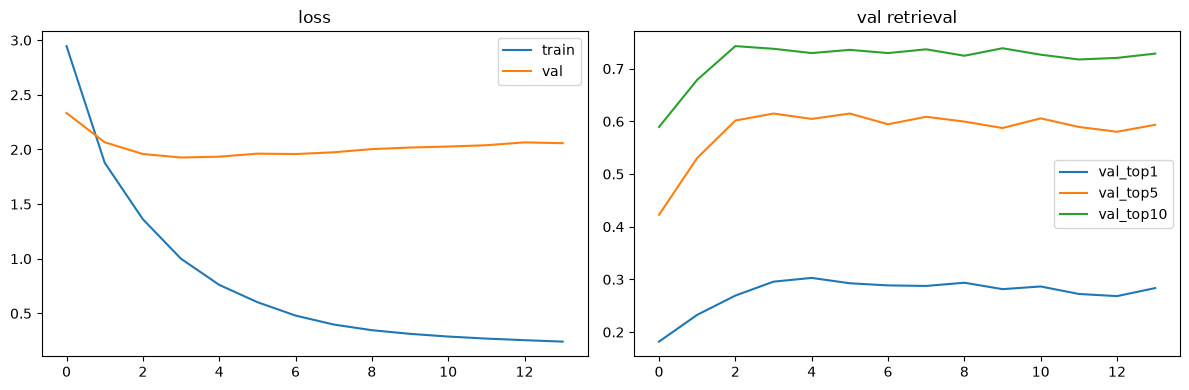

In [6]:
import pandas as pd
paths = get_experiment_paths(cfg, ensure=False)
log = pd.read_csv(paths.train_log)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(log.epoch, log.train_total, label='train')
ax[0].plot(log.epoch, log.val_loss, label='val'); ax[0].legend(); ax[0].set_title('loss')
for c in ['val_top1','val_top5','val_top10']:
    ax[1].plot(log.epoch, log[c], label=c)
ax[1].legend(); ax[1].set_title('val retrieval'); plt.tight_layout(); plt.show()

In [4]:
print('TEST metrics:'); load_json(paths.metrics / 'test_metrics.json')

TEST metrics:


{'retrieval': {'top1': 0.4716981132075472,
  'top5': 0.8679245283018868,
  'top10': 0.9559748427672956,
  'mean_rank': 3.459119496855346,
  'mean_cosine': 0.5357353687286377},
 'embedding': {'mse': 2.3991699605782544,
  'mae': 1.1485382884402078,
  'mean_cosine': 0.5357353764056197,
  'r2': -10.342576962716034,
  'mean_pearson': 0.39345574246560117,
  'median_pearson': 0.3914961694819334,
  'n': 159,
  'dim': 768},
 'loss': 1.9461789018702957}

**Takeaway:** rising Top-k and cosine on val, plus Top-k clearly above chance (`k / n_candidates`), indicate the fMRI carries CLIP-decodable information.